# Igneous Zircon U-Pb Analysis
This notebook contains code used to analyze both new and compiled igneous zircon U-Pb data to create figures for the manuscript on Moroccan rift tectonics submitted to _Tectonics_

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.gridspec import GridSpec
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from scipy.stats import rankdata

import cmcrameri.cm as cmc

from matplotlib import rc
rc("pdf", fonttype=42)

from geoscripts import maps
from geoscripts.dz import dz

/home/dyvasey/miniforge3/envs/dataset-morocco-dz-2024/lib/python3.11/site-packages/mpltern/ternary/datasets.py:9: UserWarning: `mpltern.ternary.datasets.py` has been moved to `mpltern.datasets.py` and will be removed from the present directory in mpltern 0.6.0.
  warnings.warn(msg)


In [2]:
imagery = cimgt.GoogleTiles(
    url='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'
    )

# Read map
filename = 'maps/morocco_tectonic_map.gpkg'
tect_map = gpd.read_file(filename,layer='polygons_colored')

In [3]:
dz_path = 'dz/'
smps = dz.load_all(dz_path)

smps_ig = [smp for smp in smps if 
           smp.source=='VanTongeren' and
           smp.mda>200]
print([(smp.name,smp.mda) for smp in smps_ig])

[('MR24-012', 332.29296823973976), ('MR24-016', 271.9796607153214), ('MR24-015', 268.0916511052377), ('MR24-013', 332.0253067295526)]


In [4]:
data = pd.read_csv('published_data/Atlas_C-Tr_Ig_GchronCompilation_060126.csv',index_col=0)

data_conditions = (
    (data['System']=='U-Pb') 
)

data_filtered = data[data_conditions]

data_filtered[['Longitude (DD)', 'Latitude (DD)']] = data_filtered[['Longitude (DD)', 'Latitude (DD)']].apply(pd.to_numeric, errors='coerce')

print(data_filtered.columns)
print(data_filtered.index)

Index(['Region', 'Subregion', 'Source', 'Latitude (DD)', 'Longitude (DD)',
       'Rock Type', 'Period', 'Age (Ma)', 'Error (Ma)', 'Lower Error (Ma)',
       'Error Type', 'System', 'Material', 'Technique', 'DOI',
       'Data Available', 'Notes', 'Unnamed: 18', 'Unnamed: 19',
       'UTM 29N Easting', 'UTM 29N Northing', 'Latitude (D)', 'Latitude (M)',
       'Latitude (S)', 'Longitude (D)', 'Longitude (M)', 'Longitude (S)'],
      dtype='object')
Index(['AC-1 Rim', 'AC-1 Core 1', 'AC-1 Core 2', 'AC-3', 'C-1G', 'C-6',
       'DC-39', 'DC-44', 'AC-4', 'AC-9', 'L-2 U-Pb', 'TM1G', 'BA1G', 'TA1G',
       'TZ1G', 'TC1G', 'MB2G', 'MB4G', 'NE0G', 'G1', 'AYJ0309', 'AYJ0109',
       'AYJ80', 'GS30', 'TBZ', 'KH', 'JGO1', 'JGO2', 'JGO3', 'JGO4', 'JTB1',
       'JTB2', 'JTB3', 'JTB4', 'J13A', 'Tz10/05', 'Tz10/41', 'Tz11/04',
       'Tz10/26', 'SRYN 338', 'BM 20', 'YT 304', 'YT 300', 'YT 301', 'YT 302',
       'YT 303', 'Baudin01-1', 'Baudin01-2', 'Baudin04', 'Chevremont01',
       'Ettachfini18-1

/tmp/ipykernel_2133/1217767399.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered[['Longitude (DD)', 'Latitude (DD)']] = data_filtered[['Longitude (DD)', 'Latitude (DD)']].apply(pd.to_numeric, errors='coerce')


In [5]:
for smp in smps_ig:
    data_filtered.loc[smp.name,['Latitude (DD)', 'Longitude (DD)']] = smp.latlon
    data_filtered.loc[smp.name,['Age (Ma)', 'Error (Ma)']] = smp.mda, smp.mda_err
    data_filtered.loc[smp.name,['Subregion']] = 'Jebilet'

data_filtered.sort_values(by='Age (Ma)', inplace=True, ascending=False)

# Indicate whether new data
data_filtered['New'] = data_filtered['Source'].isna()

/tmp/ipykernel_2133/1632219032.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered.loc[smp.name,['Latitude (DD)', 'Longitude (DD)']] = smp.latlon


JBD2
JBD3
JBD4
JBD5


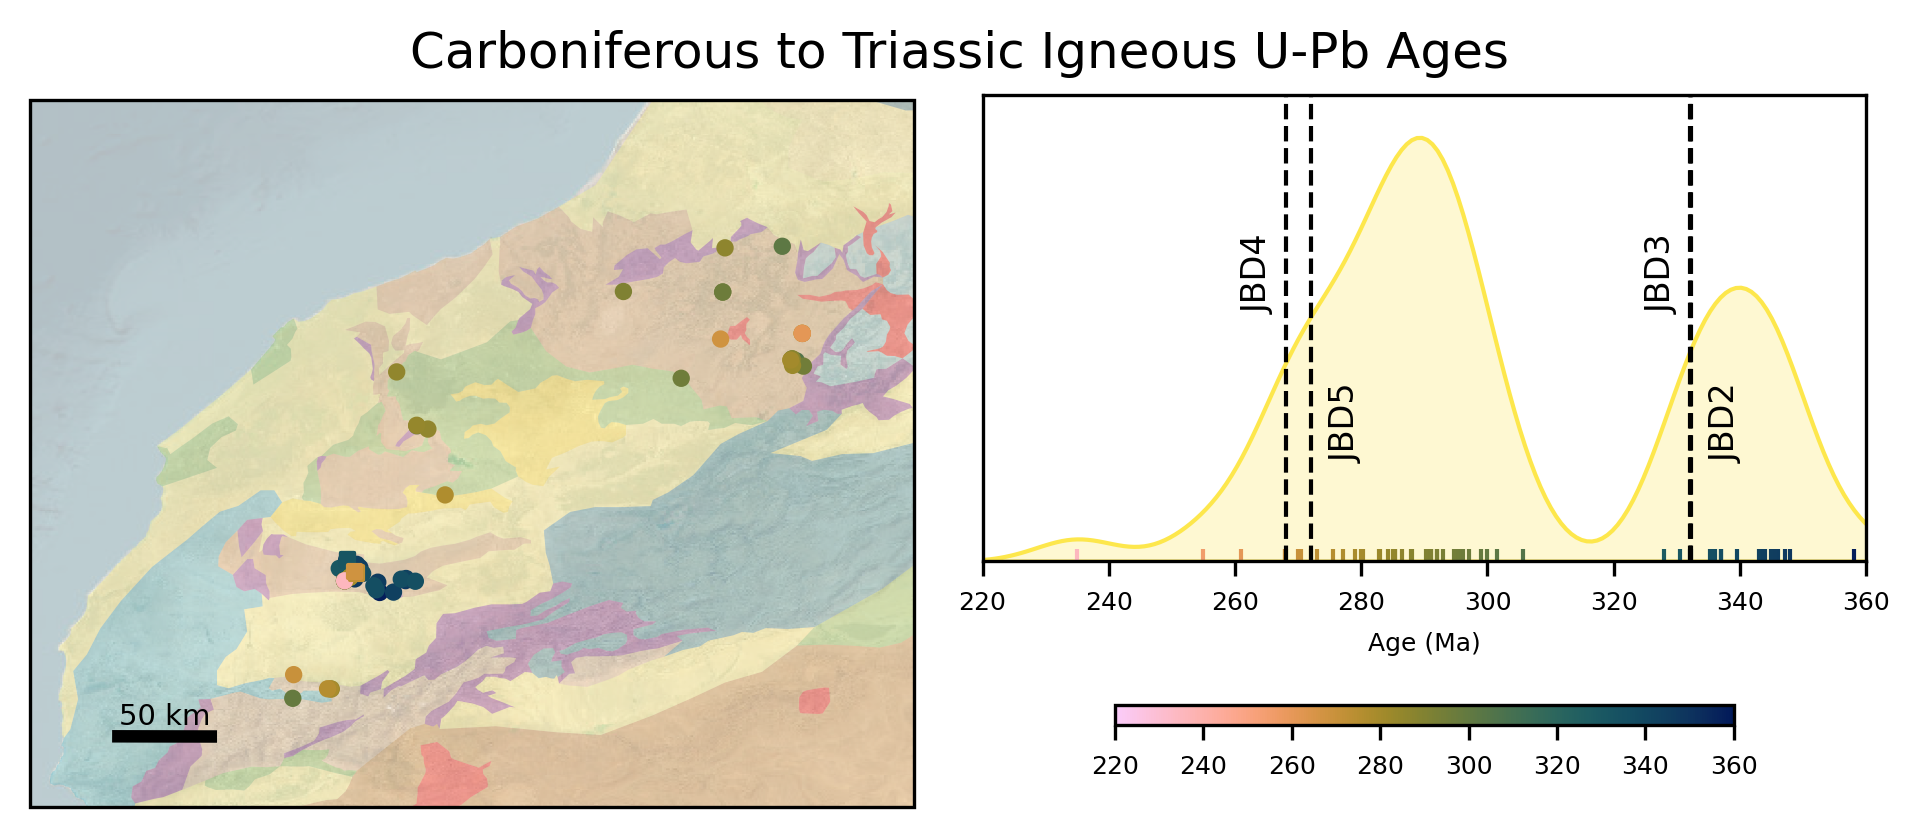

In [6]:
cmap = cmc.batlow_r

fig = plt.figure(figsize=(6.5, 3), dpi=300)

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
ax1.set_xlim(-10,-5)
ax1.set_ylim(30.5,34.5)
ax1.add_image(imagery,7,alpha=0.3)
tect_map.plot(ax=ax1,color=tect_map['unit_color'],alpha=0.3)

maps.scalebar(length=50e3,color='black',ax=ax1)

symbols = ['o','s']
groups = data_filtered.groupby('New')

for k, group in groups:

    sc = ax1.scatter(group['Longitude (DD)'],group['Latitude (DD)'],
                c=group['Age (Ma)'],cmap=cmap,s=10, marker=symbols[k],
                vmin=220,vmax=360)


ax2 = fig.add_subplot(122)
sns.kdeplot(data_filtered, x='Age (Ma)',
            ax=ax2, fill=True, legend=False, color='#fde74c', bw_adjust=0.5)
rp = sns.rugplot(data_filtered, x='Age (Ma)', hue='Age (Ma)',
            palette=cmap, legend=False,
            hue_norm=(220,360))

ax2.tick_params(axis='both', labelsize=6)
ax2.set_xlim(220,360)
ax2.set_ylabel('')
ax2.set_xlabel('Age (Ma)',fontsize=6)
ax2.set_yticks([])

cbar = plt.colorbar(sc, location='bottom', shrink=0.7, aspect=30, ax=ax2, pad=0.2)
cbar.set_ticks(np.arange(220,360+1,20))
cbar.ax.tick_params(labelsize=6)

new_names_dict = {'MR24-012':'JBD2', 'MR24-013':'JBD3', 'MR24-015':'JBD4',
                  'MR24-016':'JBD5'}

y_pos = [0.005, 0.012, 0.012, 0.005]
x_adj = [3, -7, -7, 3]

smps_ig.sort(key=lambda x:x.name)
for k, smp in enumerate(smps_ig):
    print(new_names_dict[smp.name])
    ax2.axvline(smp.mda, color='black', linestyle='--')
    ax2.text(smp.mda + x_adj[k], y_pos[k], new_names_dict[smp.name], fontsize=8, 
             rotation=90, color='black')


fig.suptitle('Carboniferous to Triassic Igneous U-Pb Ages', fontsize=12, y=0.92)
fig.tight_layout()    
fig.savefig('analysis_igneous.pdf')

In [7]:
def rank_jitter(ages, width=0.4):
    ranks = rankdata(ages, method='ordinal')
    n = len(ages)
    return (ranks - (n + 1) / 2) / n * width

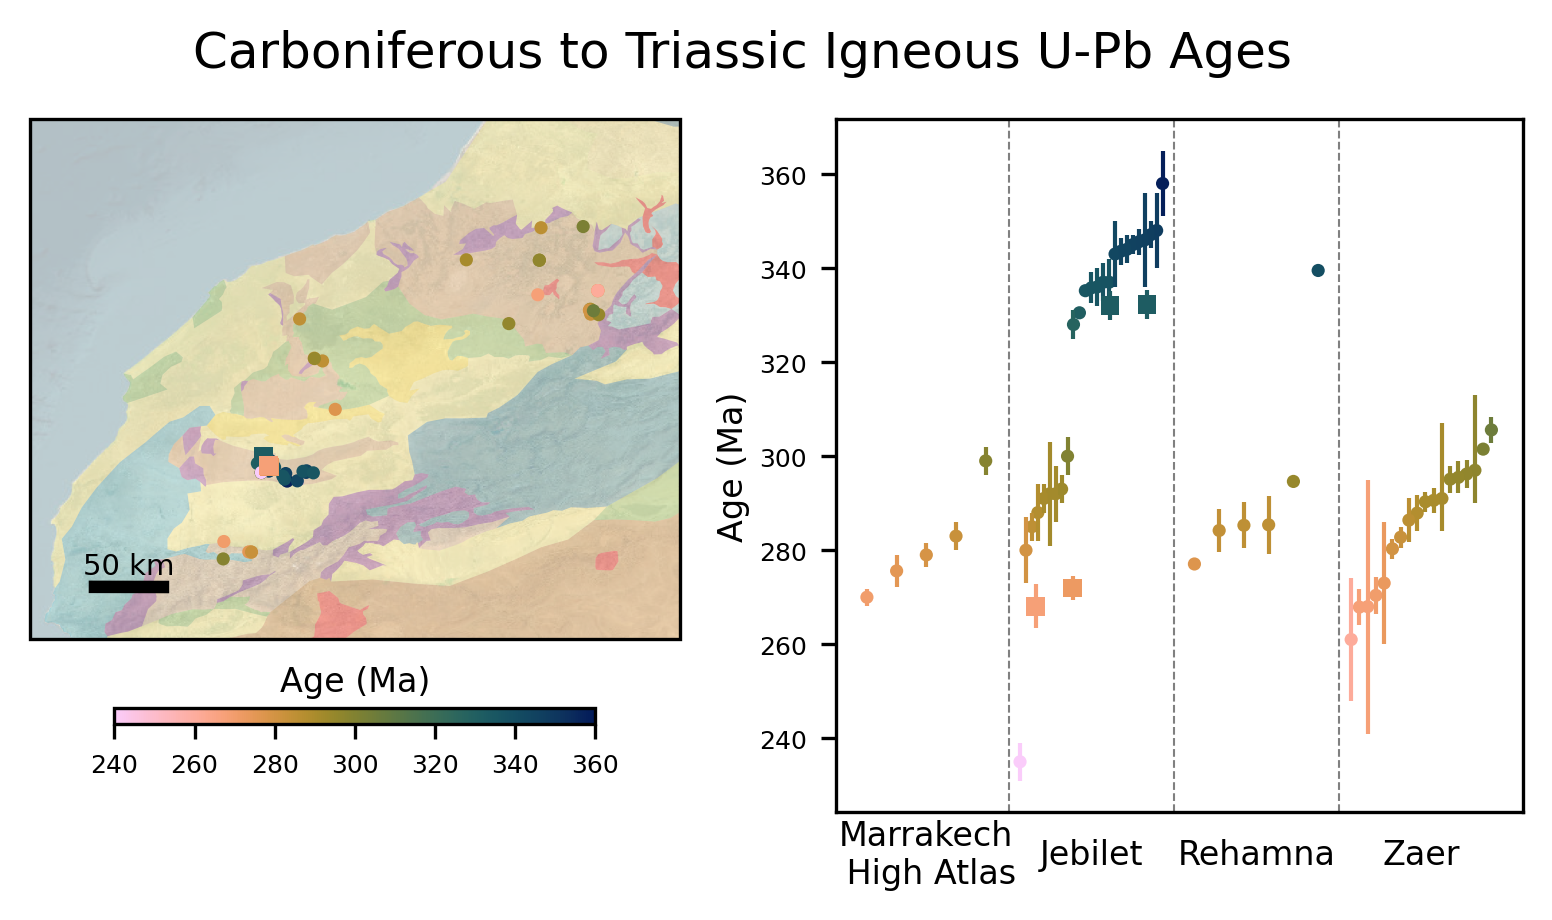

In [8]:
# Version with bar plot instead
cmap = cmc.batlow_r

fig = plt.figure(figsize=(6.5, 3), dpi=300)

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
ax1.set_xlim(-10,-5)
ax1.set_ylim(30.5,34.5)
ax1.add_image(imagery,7,alpha=0.3)
tect_map.plot(ax=ax1,color=tect_map['unit_color'],alpha=0.3)

maps.scalebar(length=50e3,color='black',ax=ax1)

ax2 = fig.add_subplot(122)

symbols = ['o','s']

rng = np.random.default_rng(1226)
norm = plt.Normalize(vmin=240, vmax=360)

data_filtered = data_filtered.copy()
data_filtered['Subregion'] = data_filtered['Subregion'].replace(
    'Marrakech', 'Marrakech\n High Atlas')

regions = ['Marrakech\n High Atlas', 'Jebilet', 'Rehamna', 'Zaer']
region_positions = {r: i for i, r in enumerate(regions)}

data_filtered = data_filtered[data_filtered['Subregion'].isin(regions)]
groups = data_filtered.sort_values('New').groupby(['Subregion', 'New'], sort=False)

for (region, new), group in groups:
    x_center = region_positions[region]
    
    if region=='Jebilet':
        offset = 0.15 if new else -0.15
    else:
        offset = 0
    
    s = 20 if new else 10
    edgecolor = None
    lw = 0
    zorder = 3 if new else 2

    #x = rng.uniform(-0.3, 0.3, len(group)) + x_center + offset
    x = rank_jitter(group['Age (Ma)'].values, width=0.9) + x_center

    sc = ax1.scatter(group['Longitude (DD)'],group['Latitude (DD)'],
                c=group['Age (Ma)'],cmap=cmap,s=s, marker=symbols[int(new)],
                norm=norm, zorder=zorder, edgecolors=edgecolor, linewidths=lw)

    ax2.scatter(x, group['Age (Ma)'], c=group['Age (Ma)'], cmap=cmap, s=s,
                marker=symbols[int(new)], norm=norm, zorder=zorder,
                edgecolors=edgecolor, linewidths=lw)
    
    colors = cmap(norm(group['Age (Ma)']))

    # Make errors symmetric or asymmetric as needed
    lower = group['Lower Error (Ma)'].fillna(group['Error (Ma)'])
    upper = group['Error (Ma)']
    yerr = np.array([lower, upper])
    ax2.errorbar(x, group['Age (Ma)'], yerr, fmt='none',
                 ecolor=colors, elinewidth=1, capsize=0)

ax2.set_xticks([])
ax2.tick_params(axis='y', labelsize=6)
ax2.set_ylabel('Age (Ma)', fontsize=8, labelpad=2)
for i, region in enumerate(regions):
    ax2.text(i, ax2.get_ylim()[0]-9, region, ha='center', va='center',
             fontsize=8, rotation=0)
    if i > 0:
        ax2.axvline(i - 0.5, color='gray', linewidth=0.5, linestyle='--')

cbar = plt.colorbar(sc, location='bottom', shrink=0.7, aspect=30, ax=ax1, pad=0.1)
cbar.set_ticks(np.arange(240,360+1,20))
cbar.set_label('Age (Ma)', fontsize=8)
cbar.ax.tick_params(labelsize=6)
cbar.ax.xaxis.set_label_position('top')

fig.suptitle('Carboniferous to Triassic Igneous U-Pb Ages', fontsize=12)
fig.savefig('analysis_igneous_bar.pdf')
fig.savefig('analysis_igneous_bar.jpg')

In [9]:
print(data_filtered['New'].value_counts())

False    54
True      4
Name: New, dtype: int64
